Промпт:
```
Ты — Data Scientist. Мне нужно создать Python-приложение в формате Jupyter Notebook для классификации сетевого трафика на нормальный (Normal) и вредоносный (DDoS). 

Входные данные:
Датасет содержит следующие признаки: Unnamed: 0, pkSeqID, stime, flgs, flgs_number, proto, proto_number, saddr, sport, daddr, dport, pkts, bytes, state, state_number, ltime, seq, dur, mean, stddev, sum, min, max, spkts, dpkts, sbytes, dbytes, rate, srate, drate, TnBPSrcIP, TnBPDstIP, TnP_PSrcIP, TnP_PDstIP, TnP_PerProto, TnP_Per_Dport, AR_P_Proto_P_SrcIP, AR_P_Proto_P_DstIP, N_IN_Conn_P_DstIP, N_IN_Conn_P_SrcIP, AR_P_Proto_P_Sport, AR_P_Proto_P_Dport, Pkts_P_State_P_Protocol_P_DestIP, Pkts_P_State_P_Protocol_P_SrcIP, attack, category, subcategory.

Целевая переменная: 'category' (принимает значения 'DDoS' или 'Normal'). В датасете присутствует критический дисбаланс классов: около 2 000 000 записей DDoS и всего около 500 записей Normal.

Твоя задача — предложить решение и написать код, разбив его на логические блоки (ячейки Jupyter Notebook) такие, как загрузка и анализ данных, подготовка данных к обучению (что удалить, как работать с дисбалансом), обучение минимум двух моделей и оценка результатов с демонстрацией матрицы ошибок и сохранением результата в result.csv
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения графиков
plt.style.use('seaborn-v0_8')


In [3]:
# Загрузка датасета
df = pd.read_csv('DDoSdata.csv')  # замените на путь к вашему файлу

# Просмотр основных характеристик данных
print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())

print("\nИнформация о данных:")
print(df.info())

print("\nСтатистика по целевой переменной:")
print(df['category'].value_counts())
print("\nРаспределение классов в процентах:")
print(df['category'].value_counts(normalize=True) * 100)


Размер датасета: (1927101, 47)

Первые 5 строк:
   Unnamed: 0  pkSeqID         stime flgs  flgs_number proto  proto_number  \
0     1650261  1650261  1.528103e+09    e            1   tcp             1   
1     1650262  1650262  1.528103e+09    e            1   tcp             1   
2     1650263  1650263  1.528103e+09    e            1   tcp             1   
3     1650264  1650264  1.528103e+09    e            1   tcp             1   
4     1650265  1650265  1.528103e+09    e            1   tcp             1   

             saddr  sport          daddr  ... AR_P_Proto_P_DstIP  \
0  192.168.100.150  54110  192.168.100.3  ...            1.21662   
1  192.168.100.150  54112  192.168.100.3  ...            1.21662   
2  192.168.100.150  54114  192.168.100.3  ...            1.21662   
3  192.168.100.150  54116  192.168.100.3  ...            1.21662   
4  192.168.100.150  54118  192.168.100.3  ...            1.21662   

   N_IN_Conn_P_DstIP  N_IN_Conn_P_SrcIP AR_P_Proto_P_Sport  \
0           

In [4]:
# Удаляем ненужные столбцы (идентификаторы и избыточные признаки)
columns_to_drop = ['Unnamed: 0', 'pkSeqID', 'stime', 'saddr', 'daddr', 
                   'ltime', 'seq', 'flgs', 'proto']

df_clean = df.drop(columns=columns_to_drop, errors='ignore')

# Проверяем оставшиеся столбцы
print("Оставшиеся столбцы после очистки:")
print(df_clean.columns.tolist())

# Проверка на пропуски
print("\nПропущенные значения:")
print(df_clean.isnull().sum().sum())


Оставшиеся столбцы после очистки:
['flgs_number', 'proto_number', 'sport', 'dport', 'pkts', 'bytes', 'state', 'state_number', 'dur', 'mean', 'stddev', 'sum', 'min', 'max', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'srate', 'drate', 'TnBPSrcIP', 'TnBPDstIP', 'TnP_PSrcIP', 'TnP_PDstIP', 'TnP_PerProto', 'TnP_Per_Dport', 'AR_P_Proto_P_SrcIP', 'AR_P_Proto_P_DstIP', 'N_IN_Conn_P_DstIP', 'N_IN_Conn_P_SrcIP', 'AR_P_Proto_P_Sport', 'AR_P_Proto_P_Dport', 'Pkts_P_State_P_Protocol_P_DestIP', 'Pkts_P_State_P_Protocol_P_SrcIP', 'attack', 'category', 'subcategory']

Пропущенные значения:
0


In [5]:
# Кодируем категориальные признаки (если есть)
categorical_columns = df_clean.select_dtypes(include=['object']).columns
categorical_columns = categorical_columns.drop('category', errors='ignore')

label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le

print("Категориальные признаки закодированы.")


Категориальные признаки закодированы.


In [6]:
# Разделяем признаки и целевую переменную
X = df_clean.drop('category', axis=1)
y = df_clean['category']

# Кодируем целевую переменную
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Распределение классов в обучающей выборке до балансировки:")
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

# Применяем undersampling для балансировки
undersampler = RandomUnderSampler(sampling_strategy=0.5, random_state=42)
X_train_balanced, y_train_balanced = undersampler.fit_resample(X_train, y_train)

print("\nРаспределение классов после балансировки:")
unique_balanced, counts_balanced = np.unique(y_train_balanced, return_counts=True)
print(dict(zip(unique_balanced, counts_balanced)))


Распределение классов в обучающей выборке до балансировки:
{np.int64(0): np.int64(1541298), np.int64(1): np.int64(382)}

Распределение классов после балансировки:
{np.int64(0): np.int64(764), np.int64(1): np.int64(382)}


In [7]:
# Нормализация признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

print("Признаки нормализованы.")


Признаки нормализованы.


In [8]:
# Обучение логистической регрессии
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train_balanced)

# Предсказания
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Оценка модели
print("Результаты логистической регрессии:")
print(classification_report(y_test, y_pred_lr, target_names=['Normal', 'DDoS']))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_lr))


Результаты логистической регрессии:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    385326
        DDoS       0.96      1.00      0.98        95

    accuracy                           1.00    385421
   macro avg       0.98      1.00      0.99    385421
weighted avg       1.00      1.00      1.00    385421

ROC-AUC: 1.0


In [9]:
# Обучение случайного леса
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train_balanced)

# Предсказания
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Оценка модели
print("Результаты случайного леса:")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'DDoS']))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_rf))


Результаты случайного леса:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    385326
        DDoS       0.94      1.00      0.97        95

    accuracy                           1.00    385421
   macro avg       0.97      1.00      0.98    385421
weighted avg       1.00      1.00      1.00    385421

ROC-AUC: 1.0


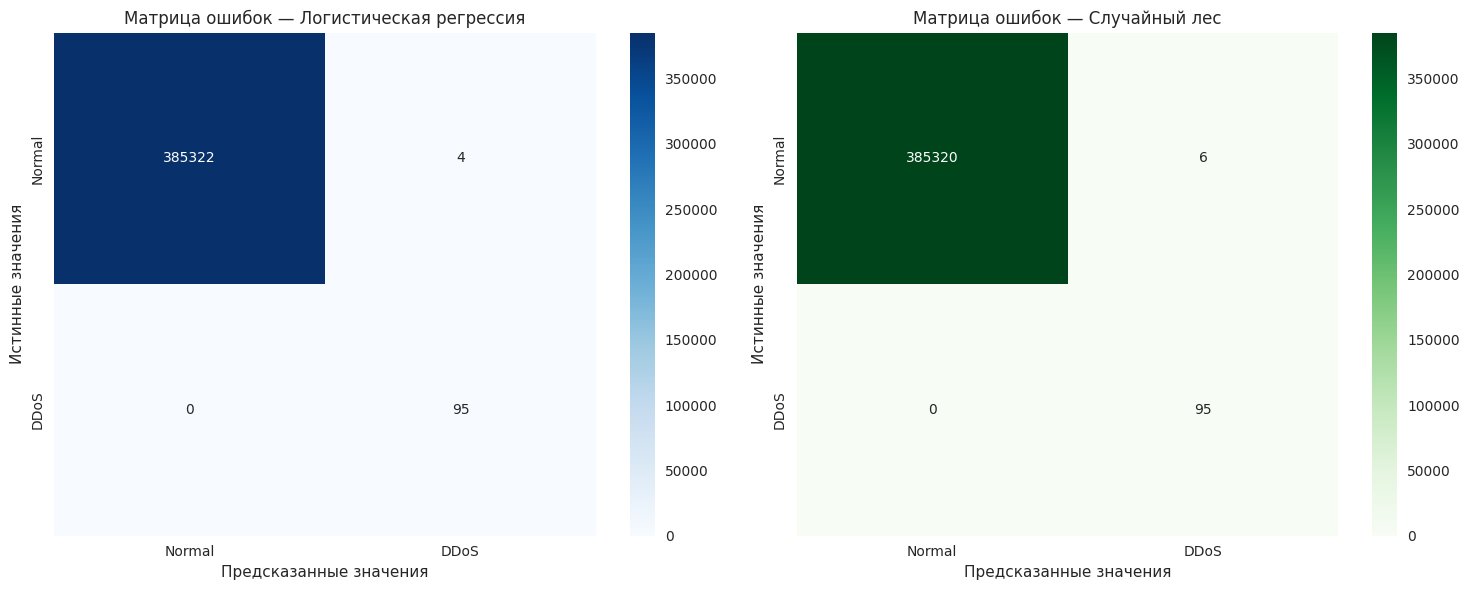

In [10]:
# Создание графиков для сравнения моделей
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Матрица ошибок для логистической регрессии
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'DDoS'], yticklabels=['Normal', 'DDoS'], ax=axes[0])
axes[0].set_title('Матрица ошибок — Логистическая регрессия')
axes[0].set_ylabel('Истинные значения')
axes[0].set_xlabel('Предсказанные значения')

# Матрица ошибок для случайного леса
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Normal', 'DDoS'], yticklabels=['Normal', 'DDoS'], ax=axes[1])
axes[1].set_title('Матрица ошибок — Случайный лес')
axes[1].set_ylabel('Истинные значения')
axes[1].set_xlabel('Предсказанные значения')

plt.tight_layout()
plt.show()


In [12]:
# Создаём DataFrame с результатами
results = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_LR': y_pred_lr,
    'Probability_LR': y_pred_proba_lr,
    'Predicted_RF': y_pred_rf,
    'Probability_RF': y_pred_proba_rf
})

# Декодируем метки обратно в текстовые значения
results['True_Label'] = le_target.inverse_transform(results['True_Label'])
results['Predicted_LR'] = le_target.inverse_transform(results['Predicted_LR'])
results['Predicted_RF'] = le_target.inverse_transform(results['Predicted_RF'])

# Сохраняем результаты в CSV
results.to_csv('result.csv', index=False)
print("Результаты сохранены в файл 'result.csv'")

Результаты сохранены в файл 'result.csv'
